# Visualizing Compilation and Execution

xDQC can render every stage of the pipeline: the circuit DAG, the distributed
circuit, how qubits migrate between QPUs, and the final execution schedule —
including an animation played over the network graph.

This notebook uses the small two-QPU demo so every figure stays readable.

> **Running this notebook.** From the repository root:
>
> ```bash
> uv sync
> uv run jupyter lab demo/visualization.ipynb
> ```

## Setup

Two conventions to know:

- The **matplotlib** renderers return an `Axes` and draw inline.
- The **SVG** renderers return an `SvgDocument`, whose `.svg` attribute is
  markup you can display or write to disk with `.write_svg(path)`.

`ebit_assignment=True` on `compile()` records which entangled pair each remote
operation used, which the animation needs.

In [1]:
from pathlib import Path

from IPython.display import SVG, display

from xdqc import Compiler, Scheduler

Path("outputs").mkdir(exist_ok=True)

compiler = Compiler(
    "inputs/qft_n4.qasm", "inputs/demo_network.json", algo="interaction"
)
compiler.compile(ebit_assignment=True)

scheduler = Scheduler(
    compiler,
    algo="des_link_fifo",
    modality="neutral_atom",
    entanglement_profile="demo.demo",
    algo_kwargs={"seed": 0},
)
scheduler.run()

partitioner = compiler.partitioner
circuit = compiler.circuit
schedule = partitioner.schedule
windows = partitioner.windows

print("QPUs:    ", compiler.network.num_qpus)
print("windows: ", len(windows))
print("makespan:", round(scheduler.schedule.makespan, 1), "us")

QPUs:     2
windows:  3
makespan: 93.8 us


## 1. The circuit DAG

`plot_circuit_dag` shows the *monolithic* circuit as a dependency graph — the
input to partitioning. Nodes are operations; edges are data dependencies.

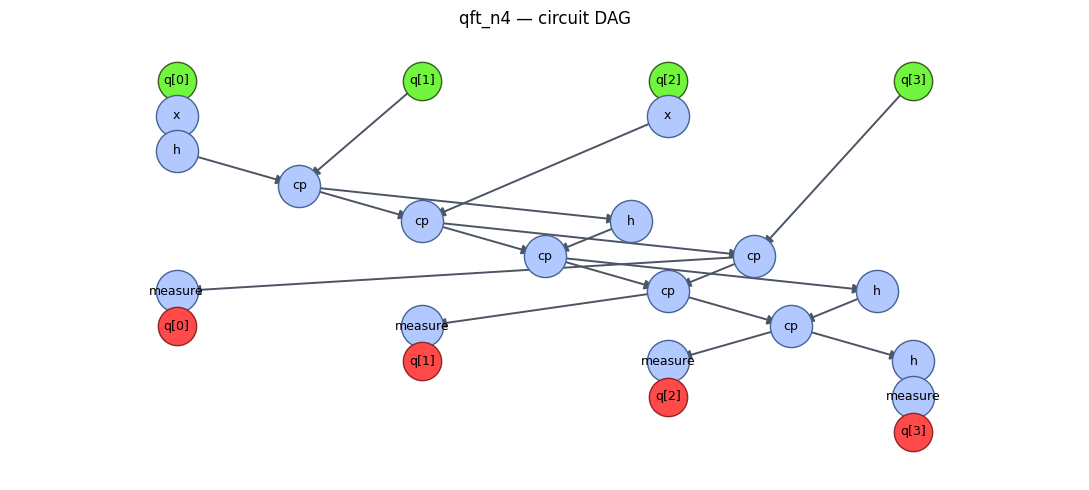

In [2]:
import matplotlib.pyplot as plt

from xdqc.visualization import plot_circuit_dag

fig, ax = plt.subplots(figsize=(11, 5))
plot_circuit_dag(circuit, ax=ax, title="qft_n4 — circuit DAG")
fig.tight_layout()
fig.savefig("outputs/circuit_dag.png", dpi=150)
plt.show()

## 2. The distributed circuit

`plot_distributed_circuit` draws the compiled result. Wires are **QPU-local
physical slots** rather than global logical qubits, so you can see which QPU
each operation lands on, and the cat-entanglement scaffolding around every
remote gate.

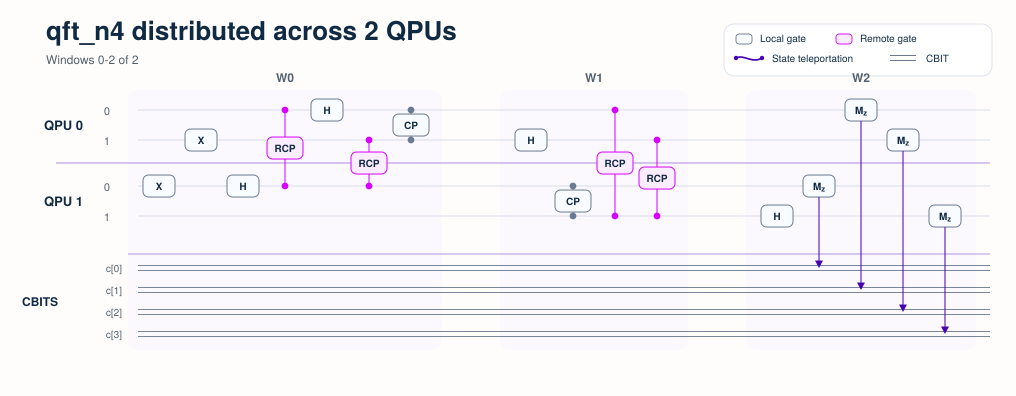

In [3]:
from xdqc.visualization import plot_distributed_circuit

document = plot_distributed_circuit(
    circuit,
    schedule=schedule,
    windows=windows,
    title="qft_n4 distributed across 2 QPUs",
)
document.write_svg("outputs/distributed_circuit.svg")
display(SVG(document.svg))

## 3. Where the qubits go

Three views of the same thing — how the partitioner assigns logical qubits to
QPUs over time.

`plot_partition_flow` is an alluvial diagram: each band is a logical qubit
moving between QPUs from one window to the next.

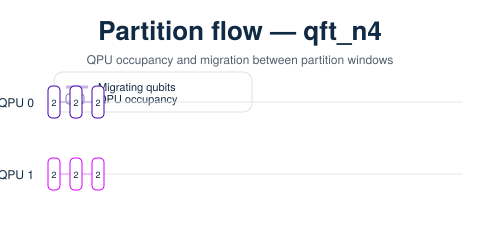

In [4]:
from xdqc.visualization import plot_partition_flow

flow = plot_partition_flow(schedule, title="Partition flow — qft_n4")
flow.write_svg("outputs/partition_flow.svg")
display(SVG(flow.svg))

`plot_partition_heatmap` is the same data as a grid: one row per logical qubit,
one column per window, coloured by QPU. Good for spotting qubits that never
settle.

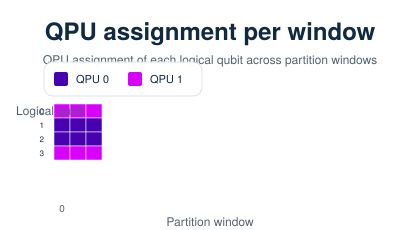

In [5]:
from xdqc.visualization import plot_partition_heatmap

heatmap = plot_partition_heatmap(schedule, title="QPU assignment per window")
heatmap.write_svg("outputs/partition_heatmap.svg")
display(SVG(heatmap.svg))

`plot_migration_timeline` counts how many qubits moved in each window, and can
overlay the entanglement cost those moves incurred.

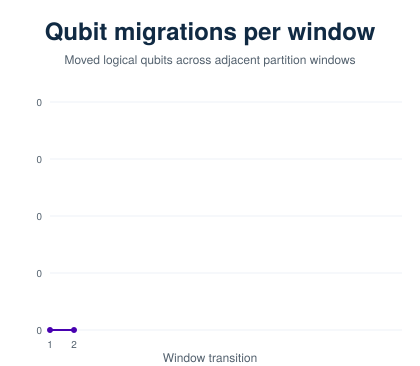

In [6]:
from xdqc.visualization import plot_migration_timeline

timeline = plot_migration_timeline(
    schedule, title="Qubit migrations per window"
)
timeline.write_svg("outputs/migration_timeline.svg")
display(SVG(timeline.svg))

## 4. Operation-level views

`plot_operation_gantt` lays the *pre-scheduling* operations out in unit-time
windows — useful for seeing structure before any hardware model is applied.

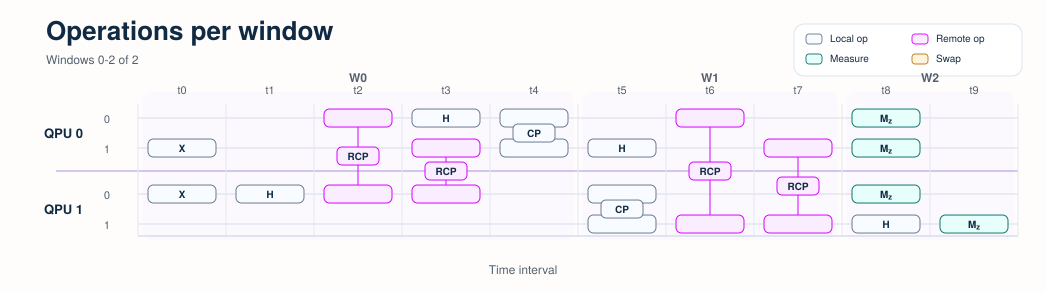

In [7]:
from xdqc.visualization import plot_operation_gantt

gantt = plot_operation_gantt(
    circuit,
    schedule=schedule,
    windows=windows,
    title="Operations per window",
)
gantt.write_svg("outputs/operation_gantt.svg")
display(SVG(gantt.svg))

`plot_window_activity` summarises how busy each window is.

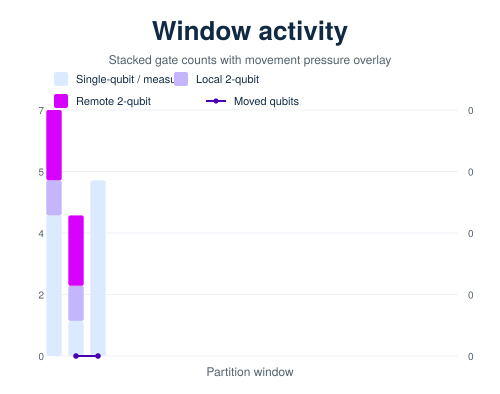

In [8]:
from xdqc.visualization import plot_window_activity

activity = plot_window_activity(
    circuit, schedule, windows, title="Window activity"
)
activity.write_svg("outputs/window_activity.svg")
display(SVG(activity.svg))

## 5. The execution schedule

This is the post-scheduling view: real durations on real hardware. `plot_gantt`
has two renderings — `"pretty"` for publication and `"legacy"` for on-screen
diagnostics.

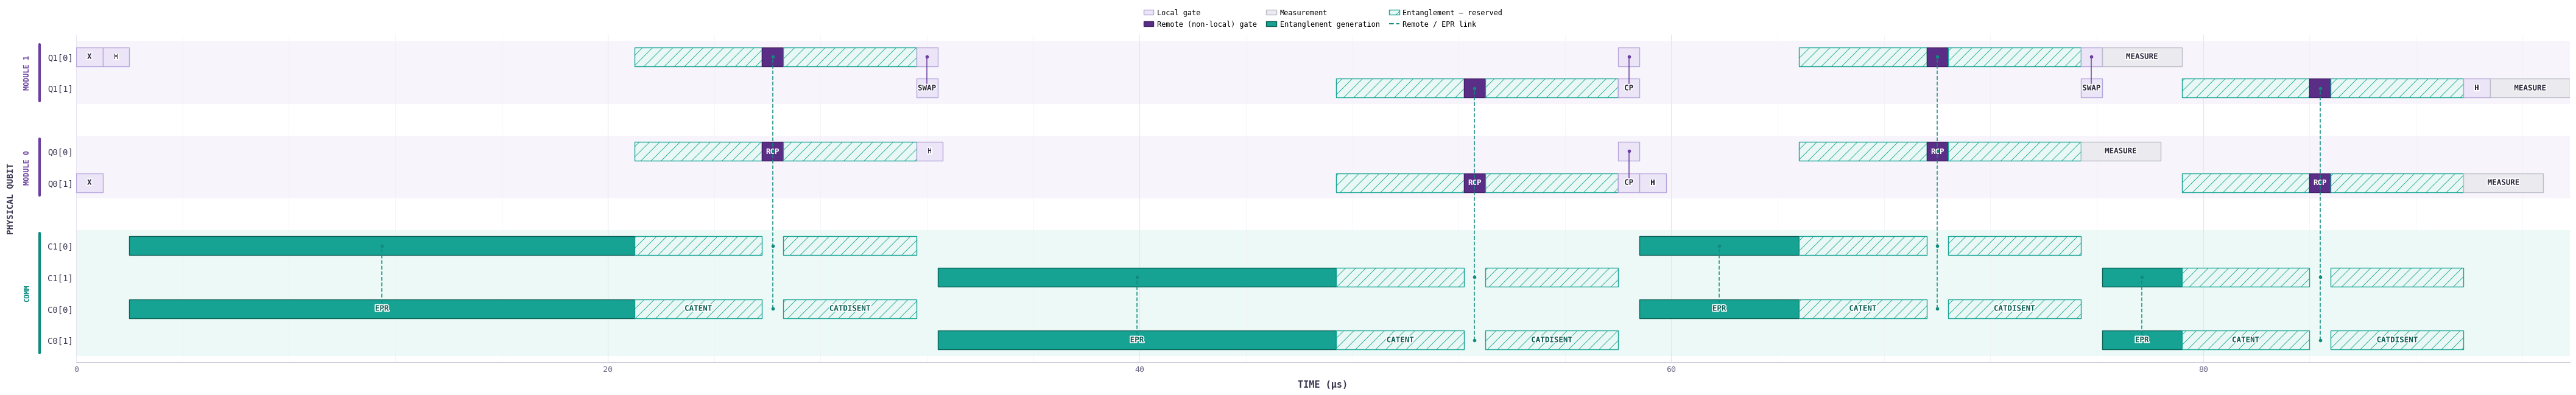

In [9]:
scheduler.plot_gantt(
    display="pretty",
    save_path="outputs/schedule_gantt_pretty.png",
);

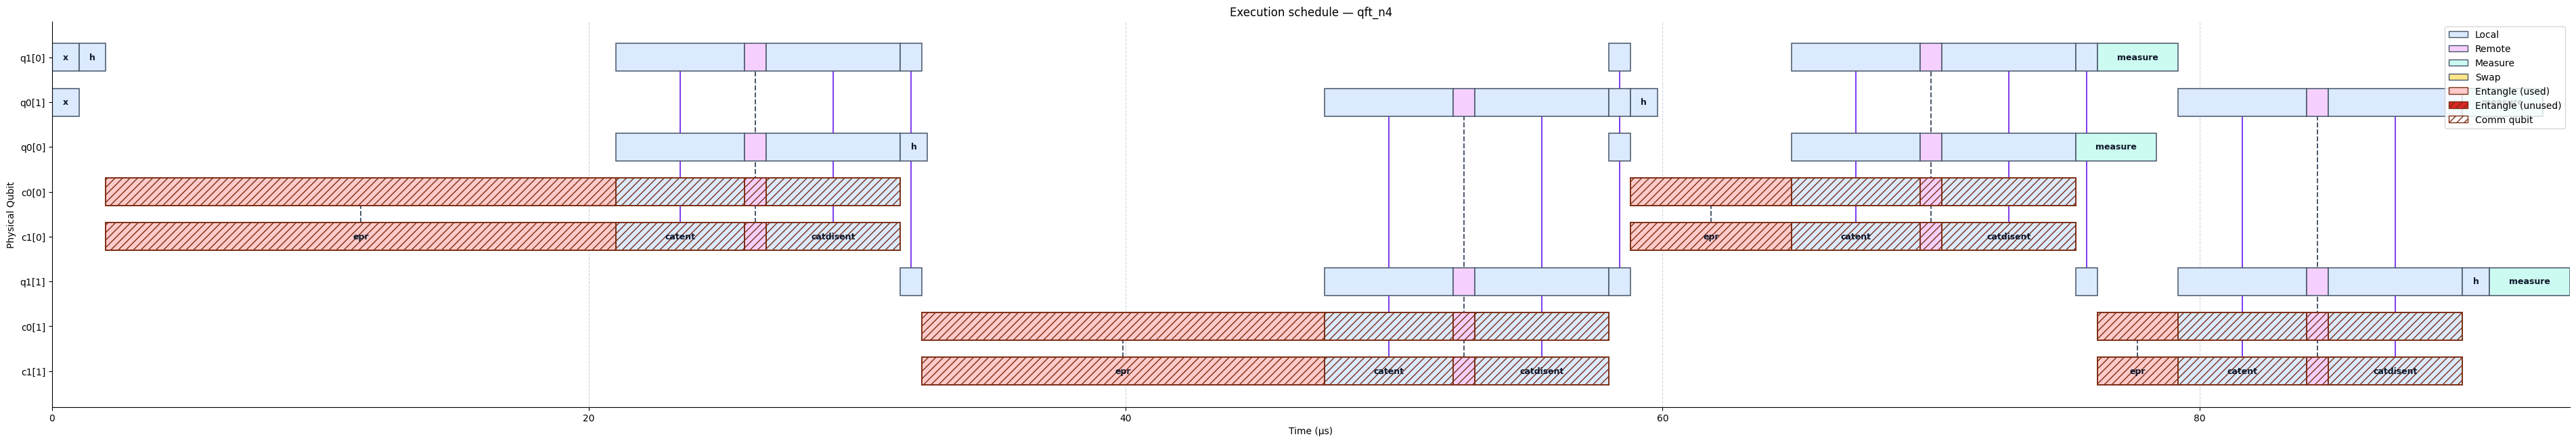

In [10]:
scheduler.plot_gantt(
    title="Execution schedule — qft_n4",
    display="legacy",
    save_path="outputs/schedule_gantt_legacy.png",
);

Each row is a physical qubit. Communication qubits (`c…`) generate entanglement
(`epr`) and run the `catent`/`catdisent` halves of each remote gate; data qubits
(`q…`) carry local gates and measurements.

## 6. Bundling panels into a dashboard

`write_svg_dashboard_html` collects SVG documents into one standalone HTML file
— no external assets, so it opens anywhere and is easy to attach to a report.

In [11]:
from xdqc.visualization import (
    SvgDashboardPanel,
    SvgDashboardSection,
    write_svg_dashboard_html,
)

sections = [
    SvgDashboardSection(
        title="Compilation",
        description="How the circuit was distributed across QPUs.",
        panels=[
            SvgDashboardPanel(title="Distributed circuit", document=document),
            SvgDashboardPanel(title="Partition flow", document=flow),
        ],
    ),
    SvgDashboardSection(
        title="Partition behaviour",
        panels=[
            SvgDashboardPanel(title="Assignment heatmap", document=heatmap),
            SvgDashboardPanel(title="Migrations", document=timeline),
        ],
    ),
]

path = write_svg_dashboard_html(
    "outputs/dashboard.html", sections, title="qft_n4 compilation report"
)
print("wrote", path, f"({path.stat().st_size // 1024} KB)")

wrote outputs/dashboard.html (35 KB)


## 7. Animating execution over the network

`animate_circuit_execution` plays the schedule back over the network graph:
nodes light up as operations run, and remote links light up while an entangled
pair is being generated or consumed.

`mode="events"` gives one frame per event boundary. The returned object renders
inline in Jupyter via `_repr_html_`, but that embeds a frame-by-frame player in
the saved file — megabytes of base64. Export a GIF and reference it instead, so
the notebook stays small.

In [12]:
from xdqc.visualization import animate_circuit_execution

animation = animate_circuit_execution(
    compiler.network,
    scheduler.schedule,
    mode="events",
    title="qft_n4 execution",
    figsize=(7, 4),
)
gif_path = Path("outputs/execution.gif")
animation.save(gif_path, fps=3, dpi=70)
plt.close("all")

print("wrote", gif_path, f"({gif_path.stat().st_size // 1024} KB)")

MovieWriter ffmpeg unavailable; using Pillow instead.


wrote outputs/execution.gif (325 KB)


![Execution animation](outputs/execution.gif)

`save()` picks its writer from the extension: `.gif` uses Pillow, `.mp4` needs
ffmpeg on the path, and `.html` writes a self-contained player. In a live
session `animation.show()` opens an interactive window, and
`animation.to_jshtml()` returns an embeddable player.

## What you produced

| File | What it is |
| --- | --- |
| `outputs/circuit_dag.png` | Monolithic circuit dependency graph |
| `outputs/distributed_circuit.svg` | Compiled circuit across QPUs |
| `outputs/partition_flow.svg` | Alluvial qubit-migration diagram |
| `outputs/partition_heatmap.svg` | QPU assignment per window |
| `outputs/migration_timeline.svg` | Migrations per window |
| `outputs/operation_gantt.svg` | Operations per window |
| `outputs/window_activity.svg` | Per-window activity summary |
| `outputs/schedule_gantt_pretty.png` | Execution schedule (publication) |
| `outputs/schedule_gantt_legacy.png` | Execution schedule (diagnostic) |
| `outputs/dashboard.html` | All panels in one standalone page |
| `outputs/execution.gif` | Animated playback over the network |

## Next

- **`comparing_partitioners.ipynb`** — quantify what these pictures show.
- **`scheduling_and_hardware.ipynb`** — change the hardware and watch the
  schedule stretch.